In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os

def plotGraph(labels, begin, end, xName, yName, plotSaveName, flip=False, xMin=None, xMax=None, yMin=None, yMax=None, horizontal=None, vertical=None):
    plt.figure()

    for file in labels: #glob.glob("graphCSV/scenario1*.csv"):
        data = pd.read_csv(file, header=None)
        if flip:
            x = data[1][begin:end].reset_index(drop=True)
            y = data[0][begin:end].reset_index(drop=True)
        else:
            x = data[0][begin:end].reset_index(drop=True)
            y = data[1][begin:end].reset_index(drop=True)
          
        label = labels.get(file, os.path.basename(file))

        if data.shape[1] >= 3:
            plt.plot(x, y, label=label, marker='o')
            annotations = data[2][begin:end].reset_index(drop=True)
            for i in range(len(x)):
                plt.text(x[i], y[i], f"{annotations[i]:.2f}", fontsize=8, ha='right', va='bottom', clip_on=True)
        else:
            plt.plot(x, y, label=label)
            annotations = ["" for _ in range(len(x))]
        
    if flip:
        plt.xlabel(yName)
        plt.ylabel(xName)
    else:
        plt.xlabel(xName)
        plt.ylabel(yName)
    
    
    if xMin is not None and xMax is not None:
        plt.xlim(xMin, xMax)
    if yMin is not None and yMax is not None:
        plt.ylim(yMin, yMax)
    #plt.yscale('log') # makes y axis logarithmic
    
    if horizontal is not None:
        plt.axhline(y=horizontal, color='red', linestyle='--')#, label=f'Allowable Error = {allowableError}')
    if vertical is not None:
        plt.axhline(y=horizontal, color='red', linestyle='--')#, label=f'Allowable Error = {allowableError}')
    
    plt.legend()
    plt.savefig(plotSaveName, dpi=300)
    plt.show()
    
    
    
def findTime(csvPath, target=1.0):
    df = pd.read_csv(csvPath, header=None, names=['x', 'y', 'z'])
    
    # Search for two z values that straddle the target
    for i in range(len(df) - 1):
        z1 = df.loc[i, 'z']
        z2 = df.loc[i+1, 'z']
        
        if z1 == target:
            return df.loc[i, 'x']
        if z2 == target:
            return df.loc[i+1, 'x']
        
        if z1 <= target <= z2:# or z2 <= target <= z1:
            # Linear interpolation for y
            x1 = df.loc[i, 'x']
            x2 = df.loc[i+1, 'x']

            # Interpolate y at target z
            xInterp = x1 + (target - z1) * (x2 - x1) / (z2 - z1)

            #print(f"Interpolated y at z={target}: {y_interp:.6f}")
            return xInterp

    #print(f"No two z-values found surrounding {target}")
    return None

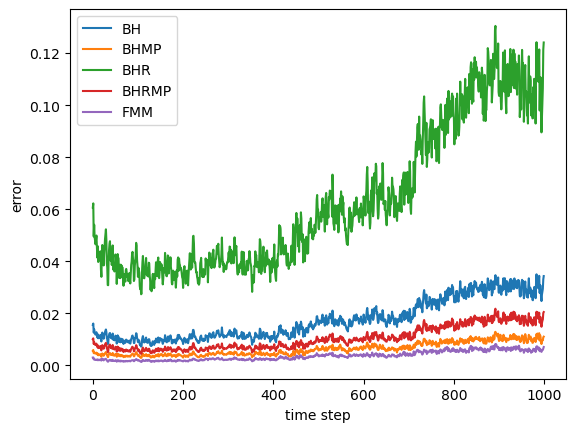

In [31]:
custom_labels = {
    os.path.join("graphCSV","gravityErrorTimestepBH_point1000_theta1.csv"): "BH",
    os.path.join("graphCSV","gravityErrorTimestepBHMP_point1000_theta1.csv"): "BHMP",
    os.path.join("graphCSV","gravityErrorTimestepBHR_point1000_theta1.csv"): "BHR",
    os.path.join("graphCSV","gravityErrorTimestepBHRMP_point1000_theta1.csv"): "BHRMP",
    os.path.join("graphCSV","gravityErrorTimestepFMM_point1000_theta1.csv"): "FMM",
}


plotGraph(custom_labels, 0, 1000, "time step", "error", "plotOutput/lines_plot.png")

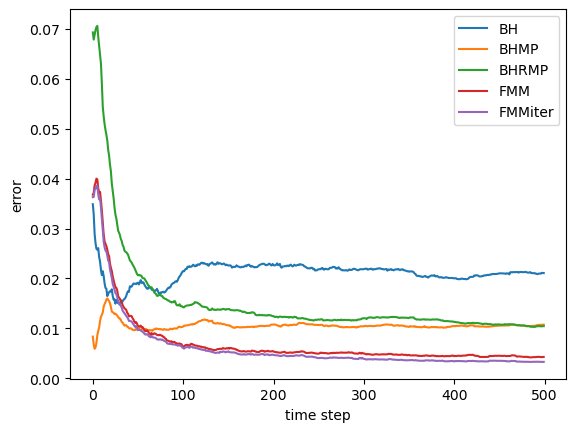

In [28]:
custom_labels = {
    os.path.join("graphCSV","tsneErrorTimestepBH_point1000_theta1.csv"): "BH",
    os.path.join("graphCSV","tsneErrorTimestepBHMP_point1000_theta1.csv"): "BHMP",
    #os.path.join("graphCSV","tsneErrorTimestepBHR_point1000_theta1.csv"): "BHR",
    os.path.join("graphCSV","tsneErrorTimestepBHRMP_point1000_theta1.csv"): "BHRMP",
    os.path.join("graphCSV","tsneErrorTimestepFMM_point1000_theta1.csv"): "FMM",
    os.path.join("graphCSV","tsneErrorTimestepFMMiter_point1000_theta1.csv"): "FMMiter",
}

plotGraph(custom_labels, 0, 1000,"time step", "error", "plotOutput/lines_plot.png")

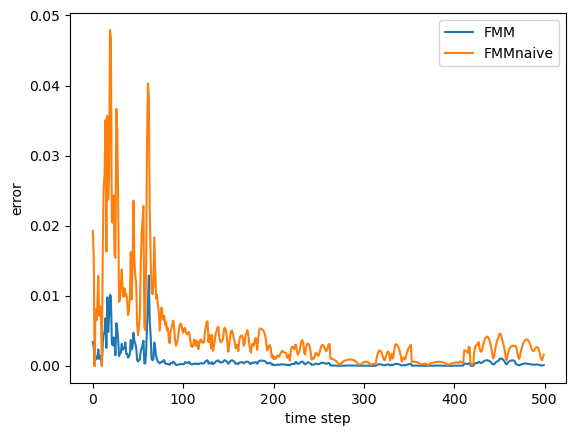

In [19]:
custom_labels = {
    os.path.join("graphCSV","gravityErrorTimestepCompareFMM_point500_theta1.csv"): "FMM",
    os.path.join("graphCSV","gravityErrorTimestepCompareFMMnaive_point500_theta1.csv"): "FMMnaive",
}

plotGraph(custom_labels, 0, 500, "time step", "error", "plotOutput/lines_plot.png")

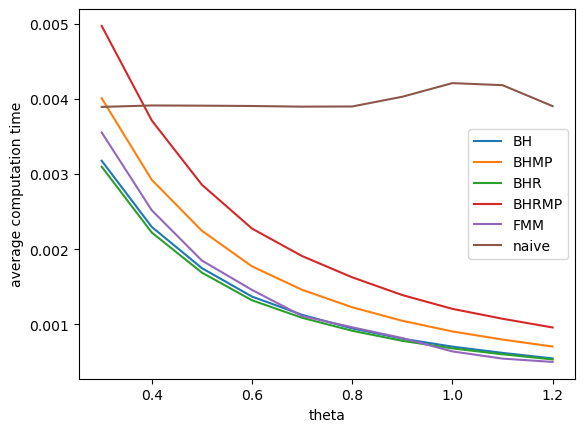

In [131]:
custom_labels = {
    os.path.join("graphCSV","gravityCalculationtimeThetaBH_point1000.csv"): "BH",
    os.path.join("graphCSV","gravityCalculationtimeThetaBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","gravityCalculationtimeThetaBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","gravityCalculationtimeThetaBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","gravityCalculationtimeThetaFMM_point1000.csv"): "FMM",
    os.path.join("graphCSV","gravityCalculationtimeThetaNaive_point1000.csv"): "naive",
}

plotGraph(custom_labels, 0, 10, "theta", "average computation time", "plotOutput/lines_plot.png")

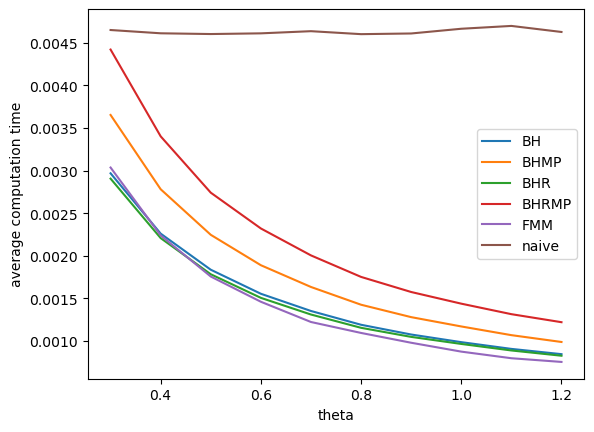

In [132]:
custom_labels = {
    os.path.join("graphCSV","tsneCalculationtimeThetaBH_point1000.csv"): "BH",
    os.path.join("graphCSV","tsneCalculationtimeThetaBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","tsneCalculationtimeThetaBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","tsneCalculationtimeThetaBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","tsneCalculationtimeThetaFMM_point1000.csv"): "FMM",
    os.path.join("graphCSV","tsneCalculationtimeThetaNaive_point1000.csv"): "naive",
}

plotGraph(custom_labels, 0, 10, "theta", "average computation time", "plotOutput/lines_plot.png")

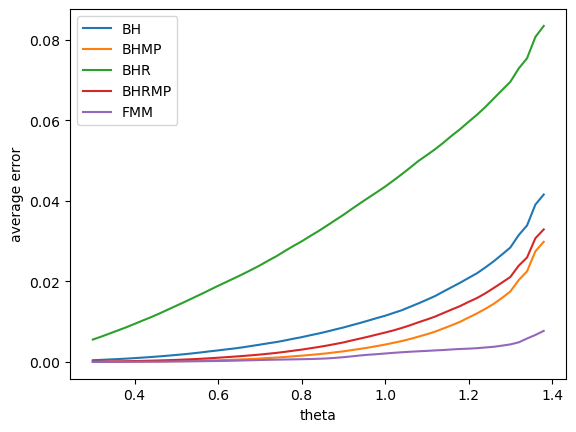

In [133]:
custom_labels = {
    os.path.join("graphCSV","gravityErrorThetaBH_point1000.csv"): "BH",
    os.path.join("graphCSV","gravityErrorThetaBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","gravityErrorThetaBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","gravityErrorThetaBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","gravityErrorThetaFMM_point1000.csv"): "FMM",
}

plotGraph(custom_labels, 0, 55,"theta", "average error", "plotOutput/lines_plot.png")

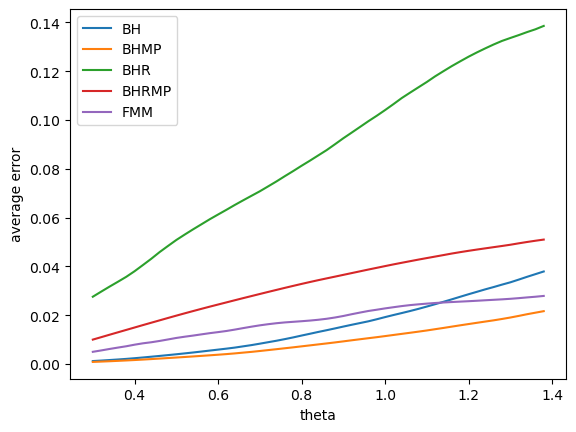

In [16]:
custom_labels = {
    os.path.join("graphCSV","tsneErrorThetaBH_point1000.csv"): "BH",
    os.path.join("graphCSV","tsneErrorThetaBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","tsneErrorThetaBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","tsneErrorThetaBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","tsneErrorThetaFMM_point1000.csv"): "FMM",
}

plotGraph(custom_labels, 0, 55,"theta", "average error", "plotOutput/lines_plot.png")

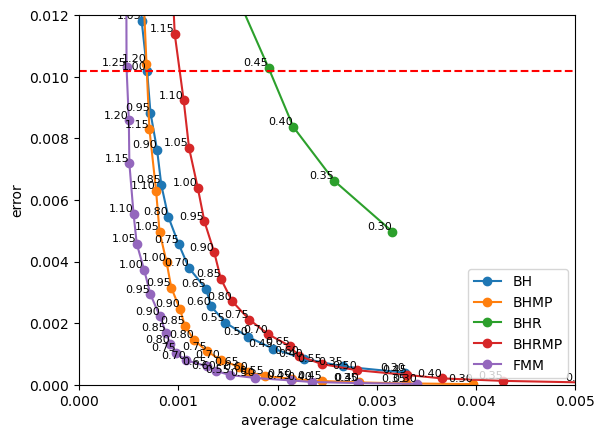

In [62]:
allowableError = findTime(os.path.join("graphCSV","gravityCalculationtimeErrorBH_point1000.csv"))

custom_labels = {
    os.path.join("graphCSV","gravityCalculationtimeErrorBH_point1000.csv"): "BH",
    os.path.join("graphCSV","gravityCalculationtimeErrorBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","gravityCalculationtimeErrorBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","gravityCalculationtimeErrorBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","gravityCalculationtimeErrorFMM_point1000.csv"): "FMM",
}


plotGraph(custom_labels, 0, 40,"error", "average calculation time", "plotOutput/lines_plot.png", True, 0, 0.005, 0, 0.012, allowableError)

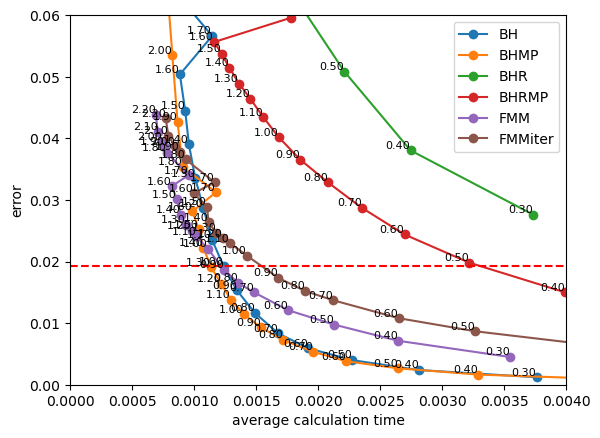

In [5]:
allowableError = findTime(os.path.join("graphCSV","tsneCalculationtimeErrorBH_point1000.csv"))


custom_labels = {
    os.path.join("graphCSV","tsneCalculationtimeErrorBH_point1000.csv"): "BH",
    os.path.join("graphCSV","tsneCalculationtimeErrorBHMP_point1000.csv"): "BHMP",
    os.path.join("graphCSV","tsneCalculationtimeErrorBHR_point1000.csv"): "BHR",
    os.path.join("graphCSV","tsneCalculationtimeErrorBHRMP_point1000.csv"): "BHRMP",
    os.path.join("graphCSV","tsneCalculationtimeErrorFMM_point1000.csv"): "FMM",
    os.path.join("graphCSV","tsneCalculationtimeErrorFMMiter_point1000.csv"): "FMMiter",
    #os.path.join("graphCSV","tsneCalculationtimeErrorFMMiterer_point1000.csv"): "FMMiterer",
}


plotGraph(custom_labels, 0, 40,"error", "average calculation time", "plotOutput/lines_plot.png", True, 0, 0.004, 0, 0.06, allowableError)